# Task

Create a convolutional neural network to process the MNIST dataset.

Compare it with a neural network with fully connected layers.

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and display data

In [169]:
from keras.datasets import mnist
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

Reminder that values take on shades of grey 0 - 255
* 0 is black
* 255 is white

In [170]:
img = X_train[0]
print (f"min:{np.amin(X_train[0])} max:{np.amax(X_train[0])}")

min:0 max:255


In [171]:
def show_images (images, labels, rows=6, cols=10):
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    for idx in range (0, rows * cols):
        ridx=idx // cols
        cidx=idx % cols
        ax= axes[ridx, cidx]
        ax.axis("off")
        ax.imshow(images[idx], cmap="gray_r")
        ax.set_title(f"{labels[idx]}")
    plt.show()    

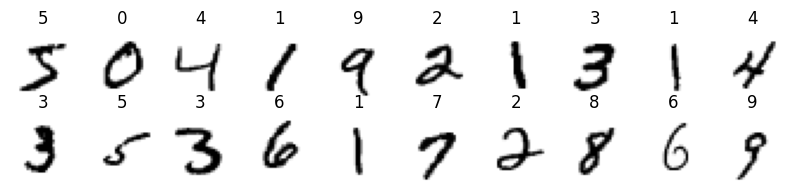

In [172]:
show_images(X_train, Y_train, 2, 10)

# Data preparation

Standardization of values from range 0 - 255 to range 0 - 1

In [173]:
X_train_dense = X_train.reshape((X_train.shape[0], X_train.shape[1] * X_train.shape[2]))
X_test_dense  = X_test.reshape((X_test.shape[0], X_test.shape[1] * X_test.shape[2]))

X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

Binary encoding

In [174]:
from keras.utils import to_categorical 
Y_train = to_categorical(Y_train, num_classes=10)
Y_test = to_categorical(Y_test, num_classes=10)

# Neural network

In [175]:
import keras
from keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from keras.models import Sequential

In [176]:
# Creating and learning the model
model = Sequential()
model.add(Input(shape=(28,28,1)))

In [177]:
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'))

In [178]:
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))

In [179]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [180]:
model.add(Dropout(0.3))

In [181]:
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

In [182]:
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.5))

In [183]:
model.add(Flatten())

In [184]:
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

In [185]:
model.add(Dense(10, activation='softmax')) 

In [186]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,306 (1.66 MB)

 Trainable params: 435,306 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [187]:
model.compile(optimizer='adam', loss="categorical_crossentropy", metrics=['accuracy'])

In [188]:
import time

In [189]:
early_stop = keras.callbacks.EarlyStopping(monitor='accuracy', patience=3)
start_time = time.time()
history = model.fit(X_train, Y_train, batch_size=64, epochs=15, callbacks=[early_stop])
training_time = time.time() - start_time

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.7203 - loss: 0.8092
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9682 - loss: 0.1092
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9778 - loss: 0.0789
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9813 - loss: 0.0644
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9825 - loss: 0.0604
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9849 - loss: 0.0538
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.9861 - loss: 0.0492
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 51ms/step - accuracy: 0.9862 - loss: 0.0465
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.9877 - loss: 0.0413
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9896 - loss: 0.0381
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9869 - loss: 0.0433
Epoch 12/15
938/938 ━━━━━━━━━━

In [190]:
model.save('classification_model_mnist.keras')

# History of learning model
- Show learning curve
- Show model accuracy curve
- Describe the shapes

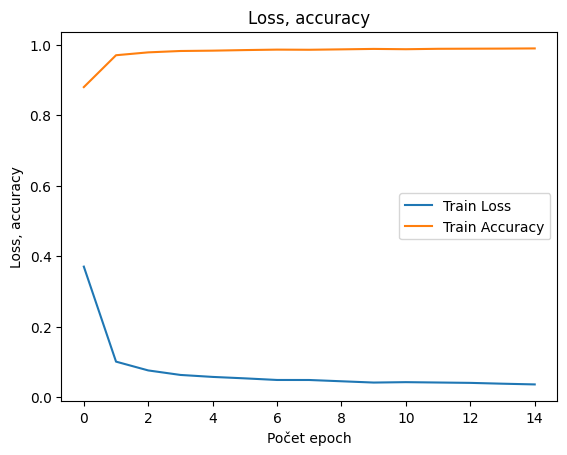

In [191]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend(loc="right")
plt.title('Loss, accuracy')
plt.ylabel('Loss, accuracy')
plt.xlabel('Počet epoch')
plt.show()

# Model Verification
- R2 score
- Accuracy of the model as a whole
- Accuracy across classes
- Change matrix
- Examples of misclassification

In [192]:
model = keras.models.load_model('classification_model_mnist.keras')

In [193]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [194]:
Y_pred_best_answer = np.argmax(Y_pred, axis=-1)
Y_pred_best_answer

array([7, 2, 1, ..., 4, 5, 6])

In [195]:
Y_test_best_answer=np.argmax(Y_test, axis=-1)
Y_test_best_answer

array([7, 2, 1, ..., 4, 5, 6])

<Axes: >

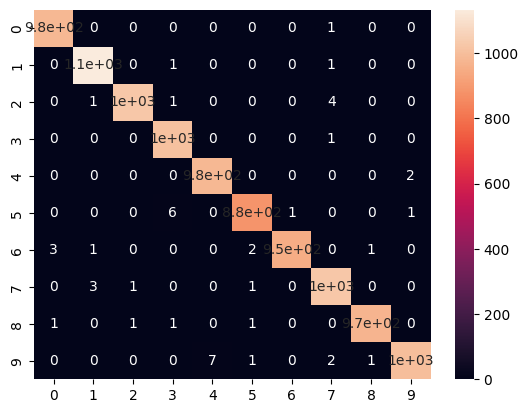

In [196]:
from sklearn.metrics import confusion_matrix, accuracy_score
cf_matrix=confusion_matrix(Y_test_best_answer, Y_pred_best_answer)
sns.heatmap(cf_matrix, annot=True)

In [197]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test_best_answer, Y_pred_best_answer)
print('R2 score: {}'.format(r2))

R2 score: 0.9891713926263127


In [198]:
scores = model.evaluate(X_test, Y_test, verbose=0)
print (f"Loss function: {scores[0]}")
print (f"Accuracy: {scores[1]}")

Loss function: 0.014849997125566006
Accuracy: 0.9952999949455261


# Model Comparison
- Which model is more accurate
- How about the learning time
- How about the time of inference

In [ ]:
Dense = keras.models.load_model('../10_ANN_classification/classification_model_mnist.keras')

start = time.time()
_ = model.predict(X_test, verbose=0)
inference_cnn = time.time() - start

start = time.time()
_ = Dense.predict(X_test_dense, verbose=0)
inference_dense = time.time() - start


print(f"Training time - Convultional Network: {training_time:.4f} seconds")
print("Training time - Artificial Network: 325 seconds")

print(f"Inference time - Convultional Network: {inference_cnn:.4f} seconds")
print(f"Inference time - Artificial Network: {inference_dense:.4f} seconds")

print (f"Accuracy - Convultional Network: {scores[1]}")  
print (f"Accuracy - Artificial Network: 0.9779999852180481")

Training time - Convultional Network: 772.0716 seconds
Training time - Artificial Network: 5 min 25 seconds
Inference time - Convultional Network: 3.3506 seconds
Inference time - Artificial Network: 0.5175 seconds
Accuracy - Convultional Network: 0.9952999949455261
Accuracy - Artificial Network: 0.9779999852180481
